## To install
`pip3 install git+https://github.com/gtcanalytics/randl_client`

In [11]:
import randl_client

#### Create an instance of the driver class

In [12]:
randl = randl_client.Randl()

#### To check current Randl settings:

In [13]:
randl

URL:http://seismic-ai.com:8011/randl/

-Bulletin-
Start:		2024-05-01T00:00:00
End:		2024-05-11T00:00:00
Stations:	100
Events:		1
Drop fraction:	0.2
Seed:	555

-Window-
Start:			2024-05-10 18:43:15.431390
Length:			1800
Min_phases:		5
Exclude associated:	False

-DML-
Models:		['pwave']
Sampling:	['full']
Num_samples:	10
Arids:		['None']
Pwave_model:	None
Baz_model:	None
Exclude stations:	True

-Beamsearch-
Beam width:	5
Max dist:	5000
Max time:	500
Sequence dist:	500
Sequence time:	500

### Randl Setter Functions
#### Bulletin Generator

`randl.set_bulletin_start('timestamp')`

`randl.set_bulletin_end('timestamp')`

`randl.set_bulletin_n_stations(int)`

`randl.set_bulletin_n_events(int)`

`randl.set_bulletin_drop_fraction(float)`

`randl.set_bulletin_seed(int)`

`bulletin = randl.create_bulletin()`

#### Windowing

`randl.set_window_start('timestamp')`

`randl.set_window_length(int)`

`randl.set_window_phases_required(int)`

`randl.set_window_exclude_associated_phases(Boolean)`

`window = randl.window_catalog(bulletin_dataframe)`

#### DML Predictions

`randl.set_dml_models(list).` Example: ['pwave', 'baz']

`randl.set_dml_sampling(list).` Example: ['kfn', 'knn', 'full', 'random']

`randl.set_dml_num_samples(int)`

`randl.set_dml_exclude_duplicate_stations(Boolean)`

`randl.set_dml_pwave_model("mlflow_model_path")`

`dml_predictions = randl.dml_prediction(window_dataframe)`

#### Beamsearch

`randl.set_beamwidth(int)`

`randl.set_beam_maxdist(int)`

`randl.set_beam_maxtime(int)`

`randl.set_beam_sequencedist(int)`

`randl.set_beam_sequencetimedist(int)`

`randl.beamsearch(window_dataframe, dml_predictions_dataframe)`

### Example Run

In [61]:
randl.set_bulletin_start('2024-05-01T00:00:00')
randl.set_bulletin_end('2024-05-01T2:30:00')
randl.set_bulletin_n_stations(100)
randl.set_bulletin_n_events(1)
randl.set_bulletin_drop_fraction(0.2)
randl.set_bulletin_seed(111)
bulletin = randl.create_bulletin()

randl.set_window_start(bulletin.loc[0,"TIME_ARRIV"])
randl.set_window_length(2800)
randl.set_window_phases_required(5)
randl.set_window_exclude_associated_phases(False)
window = randl.window_catalog(bulletin)

randl.set_dml_models(['pwave'])
randl.set_dml_sampling(['kfn'])
randl.set_dml_num_samples(30)
randl.set_dml_exclude_duplicate_stations(True)
dml_predictions = randl.dml_prediction(window)

randl.set_beamwidth(5)
randl.set_beam_maxdist(1000)
randl.set_beam_maxtime(100)
randl.set_beam_sequencedist(300)
randl.set_beam_sequencetimedist(100)
beam_result = randl.beamsearch(window, dml_predictions)

### Plotting result

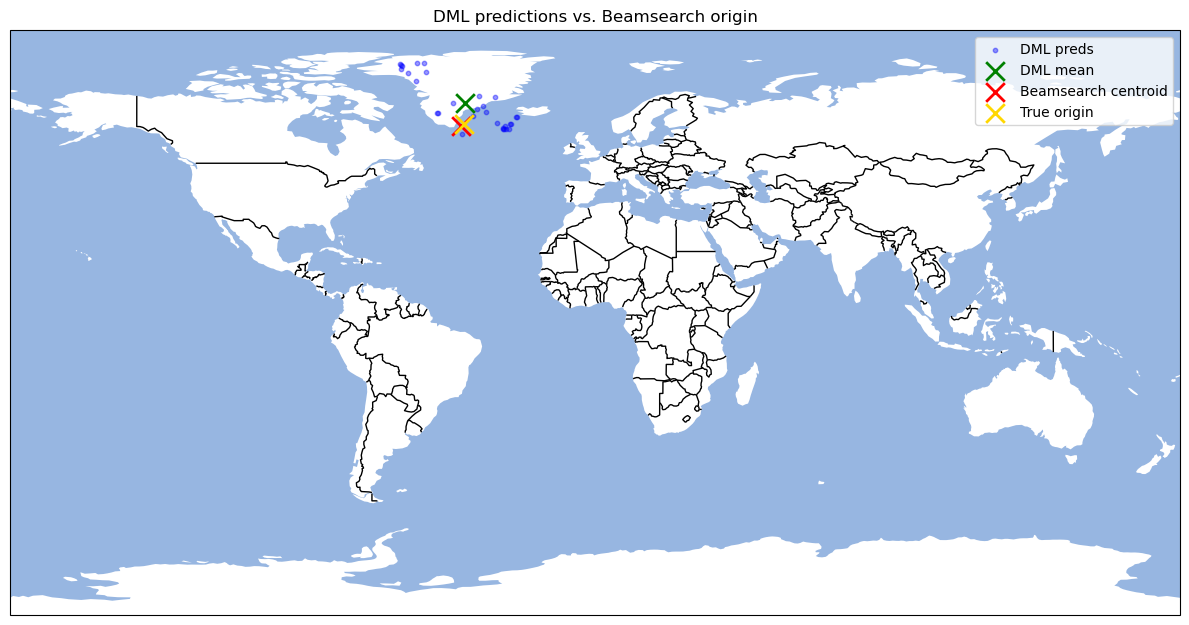

origin lat:     60.9805442979
dml_mean  lat:  67.53099289684333
beamsearch lat: 60.481928503294974
origin lon:     -40.2496747424
dml_mean  lon:  -39.90973985359334
beamsearch lon: -41.104565368835885


In [62]:
import matplotlib.pyplot as plt
from statistics import mean
import cartopy
from dateutil import parser

origin_time = bulletin.loc[0,"ORIG_TIME"]
origin_lon = bulletin.loc[0,"ORIG_LON"]
origin_lat = bulletin.loc[0,"ORIG_LAT"]
dml_lat_mean = mean(dml_predictions.LAT_ORIG)
dml_lon_mean = mean(dml_predictions.LON_ORIG)
beamsearch_lon = beam_result['centroid'][0]

beamsearch_lat = beam_result['centroid'][1]
beamsearch_time = parser.parse(beam_result['time'])

plt.rcParams['figure.figsize'] = [12,12]
geo_axes = plt.axes(projection=cartopy.crs.PlateCarree())
geo_axes.add_feature(cartopy.feature.BORDERS)
geo_axes.add_feature(cartopy.feature.OCEAN)
geo_axes.scatter(dml_predictions['LON_ORIG'], dml_predictions['LAT_ORIG'], marker='.', s=40, linewidth=1, c='b', alpha=0.4, label="DML preds")
geo_axes.scatter(dml_lon_mean, dml_lat_mean, marker='x', linewidth=2, c='g', s=180, alpha=1, label="DML mean")
geo_axes.scatter(beamsearch_lon, beamsearch_lat, marker='x', linewidth=2, c='r', s=180, alpha=1, label="Beamsearch centroid")
geo_axes.scatter(origin_lon, origin_lat, marker='x', linewidth=2, c='gold', s=180, alpha=1, label="True origin")
geo_axes.set_global()

plt.title("DML predictions vs. Beamsearch origin")
plt.legend()
plt.tight_layout()
plt.show()

print("origin lat:    ", origin_lat)
print("dml_mean  lat: ", dml_lat_mean)
print("beamsearch lat:", beamsearch_lat)

print("origin lon:    ", origin_lon)
print("dml_mean  lon: ", dml_lon_mean)
print("beamsearch lon:", beamsearch_lon)

# Full bulletin association
### 6 hour bulletin with 6 events from 50 stations

In [51]:
randl.set_bulletin_start('2024-05-01T00:00:00')
randl.set_bulletin_end('2024-05-01T6:00:00')
randl.set_bulletin_n_stations(50)
randl.set_bulletin_n_events(6)
randl.set_bulletin_drop_fraction(0.2)
randl.set_bulletin_seed(123)
bulletin = randl.create_bulletin()

### Full bulletin association function
`randl.associate_bulletin(bulletin, required_phases=5, exclude_associated_phases=False, travel_time=900, verbose=True)`

In [52]:
origins = randl.associate_bulletin(bulletin, travel_time=600, verbose=False)
origins

7 origins found in bulletin.


,Window_start,Window_end,DML_mean_lat,DML_mean_lon,Beamsearch_lat,Beamsearch_lon,Beamsearch_time,Beamsearch_score
0,2024-05-01 00:42:03.559645,2024-05-01 00:50:39.042712,61.916225,-47.658238,63.782377,-56.494199,2024-05-01 00:38:22.575123,0.018152
1,2024-05-01 00:52:53.530864,2024-05-01 01:00:03.453970,-17.735599,17.195371,-18.522322,17.96186,2024-05-01 00:47:48.497437,0.014574
2,2024-05-01 01:57:29.797827,2024-05-01 02:07:09.944160,-31.528444,29.64526,-29.17384,28.613004,2024-05-01 01:56:19.047821,0.007459
3,2024-05-01 02:02:35.300423,2024-05-01 02:08:27.576661,-34.676057,28.899605,-33.935109,27.616852,2024-05-01 01:56:41.588406,0.01933
4,2024-05-01 03:09:18.392206,2024-05-01 03:17:20.012495,63.594509,-119.431934,61.491081,-116.736659,2024-05-01 03:05:18.496562,0.041316
5,2024-05-01 04:00:38.178038,2024-05-01 04:10:23.449208,-26.943317,15.632546,-23.789608,7.787141,2024-05-01 03:58:40.445593,0.01604
6,2024-05-01 04:05:54.545233,2024-05-01 04:12:34.162087,8.063876,119.736366,9.939618,120.726785,2024-05-01 04:00:40.722824,0.029176


### Removing low scoring beamsearch origins

In [53]:
origins_trimmed = origins[origins.Beamsearch_score > 0.008]

### Plotting origins found in full bulletin vs true origins
The size of each Beamsearch centroid is from the calculated beamsearch score. Larger circles indicate stronger predictions

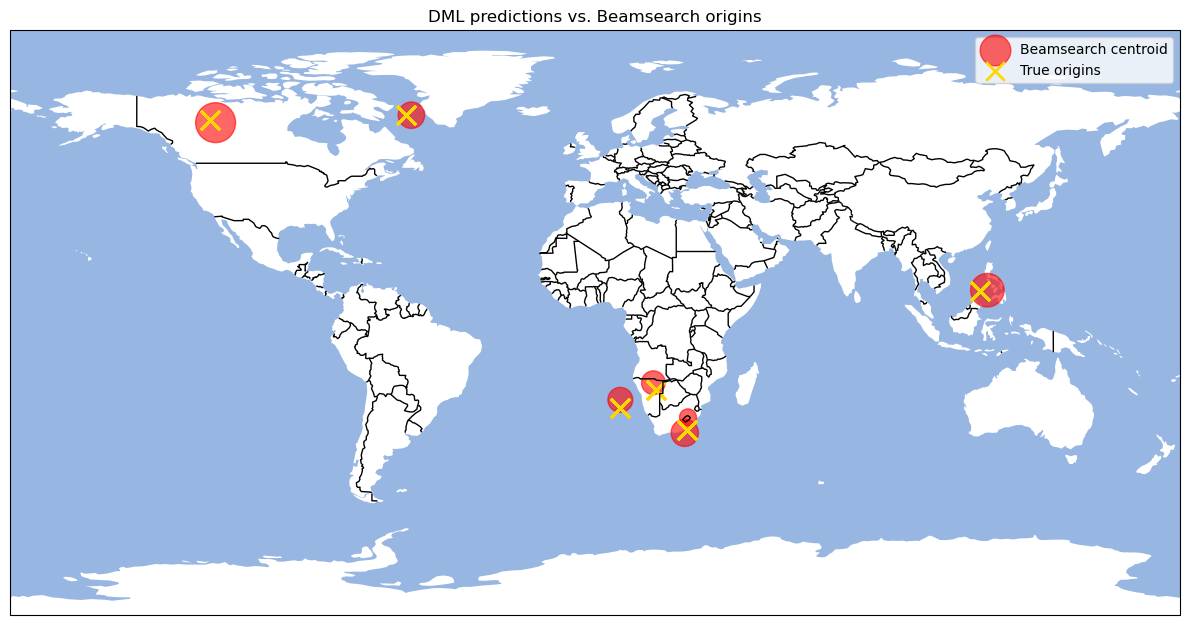

In [54]:
import matplotlib.pyplot as plt
from statistics import mean
import cartopy

plt.rcParams['figure.figsize'] = [12,12]

beam_sizes = [x*20000 for x in origins.Beamsearch_score.tolist()]

geo_axes = plt.axes(projection=cartopy.crs.PlateCarree())
geo_axes.add_feature(cartopy.feature.BORDERS)
geo_axes.add_feature(cartopy.feature.OCEAN)
geo_axes.scatter(origins.Beamsearch_lon, origins.Beamsearch_lat, c='r', s=beam_sizes, alpha=0.6, label="Beamsearch centroid")
geo_axes.scatter(bulletin.ORIG_LON, bulletin.ORIG_LAT, marker='x', linewidth=2, c='gold', s=180, alpha=1, label="True origins")
geo_axes.set_global()

plt.title("DML predictions vs. Beamsearch origins")
plt.legend()
plt.tight_layout()
plt.show()

### Full association of 16 hour bulletin with 20 events from 80 stations

In [28]:
randl.set_bulletin_start('2024-05-01T00:00:00')
randl.set_bulletin_end('2024-05-01T16:00:00')
randl.set_bulletin_n_stations(80)
randl.set_bulletin_n_events(20)
randl.set_bulletin_drop_fraction(0.2)
randl.set_bulletin_seed(23)
bulletin = randl.create_bulletin()

In [48]:
origins = randl.associate_bulletin(bulletin, travel_time=900, verbose=False)

26 origins found in bulletin.


#### Removing low scoring beamsearch origins

In [49]:
origins_trimmed = origins[origins.Beamsearch_score > 0.002]
origins_trimmed

,Window_start,Window_end,DML_mean_lat,DML_mean_lon,Beamsearch_lat,Beamsearch_lon,Beamsearch_time,Beamsearch_score
0,2024-05-01 00:49:40.676046,2024-05-01 01:01:01.757574,-85.259439,27.994188,-86.273715,54.56808,2024-05-01 00:48:40.504622,0.042435
1,2024-05-01 02:01:02.232062,2024-05-01 02:07:38.581066,48.358435,116.318808,49.04423,114.122683,2024-05-01 01:55:15.706392,0.031403
2,2024-05-01 02:19:41.340742,2024-05-01 02:34:28.913221,-65.915133,93.710211,-63.84936,155.383672,2024-05-01 02:16:35.624573,0.0025
3,2024-05-01 02:21:19.008719,2024-05-01 02:35:54.257476,-40.243229,-30.986196,-83.378451,-20.085764,2024-05-01 02:18:25.556735,0.002746
6,2024-05-01 02:58:40.195673,2024-05-01 03:13:05.094507,-55.996248,-122.293903,-51.594745,-162.850929,2024-05-01 02:56:21.517552,0.009735
7,2024-05-01 03:07:28.716369,2024-05-01 03:20:47.686443,59.744697,-63.002147,62.971667,-54.047784,2024-05-01 03:06:51.575692,0.0029
10,2024-05-01 03:58:36.562208,2024-05-01 04:08:46.725909,-41.260197,-10.296872,-39.196524,-11.926421,2024-05-01 03:56:50.960357,0.030386
11,2024-05-01 04:15:24.976743,2024-05-01 04:26:00.771392,2.534343,-118.19933,1.743318,-117.528028,2024-05-01 04:13:32.822848,0.044816
12,2024-05-01 06:02:38.469507,2024-05-01 06:17:16.607590,-12.89944,-46.532064,-34.196635,-69.324949,2024-05-01 05:57:50.870782,0.002066
13,2024-05-01 06:06:42.142906,2024-05-01 06:17:56.012018,52.97906,-115.816462,79.257222,-161.347327,2024-05-01 06:05:34.011106,0.029243


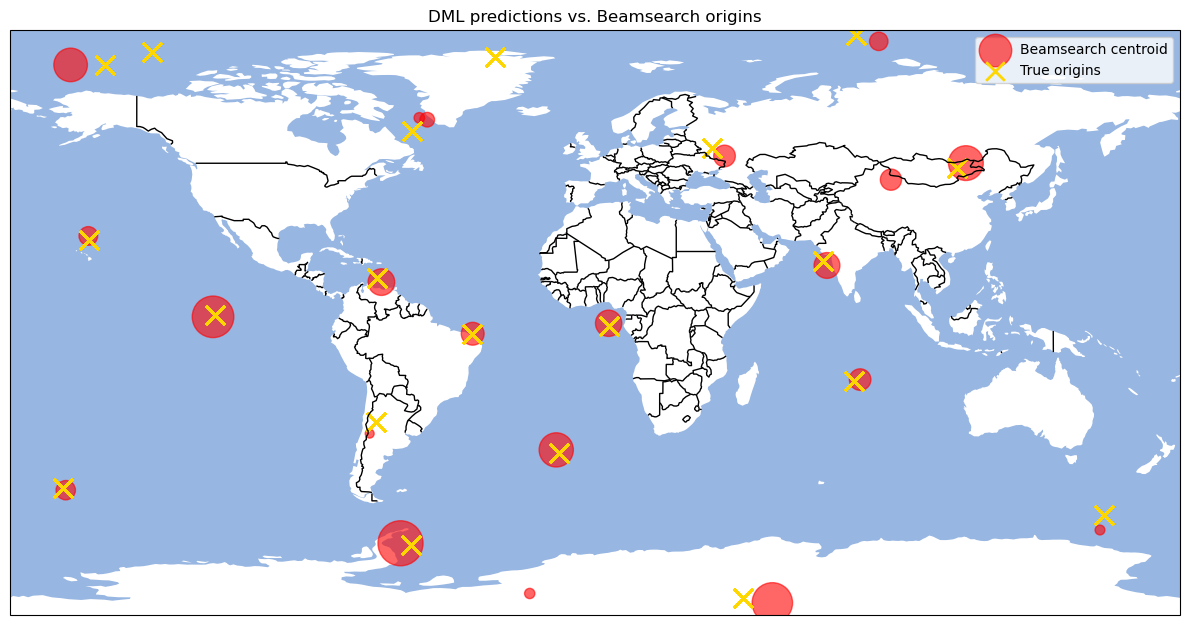

In [50]:
import matplotlib.pyplot as plt
from statistics import mean
import cartopy

plt.rcParams['figure.figsize'] = [12,12]

beam_sizes = [x*20000 for x in origins_trimmed.Beamsearch_score.tolist()]

geo_axes = plt.axes(projection=cartopy.crs.PlateCarree())
geo_axes.add_feature(cartopy.feature.BORDERS)
geo_axes.add_feature(cartopy.feature.OCEAN)
geo_axes.scatter(origins_trimmed.Beamsearch_lon, origins_trimmed.Beamsearch_lat, c='r', s=beam_sizes, alpha=0.6, label="Beamsearch centroid")
geo_axes.scatter(bulletin.ORIG_LON, bulletin.ORIG_LAT, marker='x', linewidth=2, c='gold', s=180, alpha=1, label="True origins")
geo_axes.set_global()

plt.title("DML predictions vs. Beamsearch origins")
plt.legend()
plt.tight_layout()
plt.show()